In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from numba import jit

mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['font.size'] = 16               # 본문 크기
mpl.rcParams['axes.labelsize'] = 18         # 축 라벨
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16
mpl.rcParams['legend.fontsize'] = 16
mpl.rcParams['mathtext.fontset'] = 'cm'      # LaTeX 수식은 Computer Modern 유지
mpl.rcParams['axes.linewidth'] = 1.0   # 

In [2]:
from Simul import get_RQ_MOA4,get_RQ_MOA5,get_RQ_MOA2,get_R_simul_wfT,RK4,to_complex
import numpy as np
import matplotlib.pyplot as plt
from parfor import parfor

In [3]:
alphas = np.linspace(0,np.pi/2,100)
betas = np.linspace(0,1,101)[1:]

In [4]:
SIM = np.load('SIMUL N10000/ALPHA pi4 mu 0.5.npz')

In [5]:
A =  np.load(f'SIMUL N10000/alpha = {alphas[0]}.npz')
N = 10000
Q1s = np.zeros((100,100,len(A['Q1'][0])))
Q2s = np.zeros((100,100,len(A['Q2'][0])))
R1s = np.zeros((100,100,len(A['R1'][0])))
R2s = np.zeros((100,100,len(A['R2'][0])))
for i,beta in enumerate(betas):
    A =  np.load(f'SIMUL OA/beta = {beta} N = {N}.npz')
    Q1s[i,:,:] = A['Q1']
    Q2s[i,:,:] = A['Q2']
    R2s[i,:,:] = A['R2']
    R1s[i,:,:] = A['R1']
Q1s_sim = np.zeros((100,100,len(A['Q1'][0])))
Q2s_sim = np.zeros((100,100,len(A['Q2'][0])))
R1s_sim = np.zeros((100,100,len(A['R1'][0])))
R2s_sim = np.zeros((100,100,len(A['R2'][0])))
for i,alpha in enumerate(alphas):
    A =  np.load(f'SIMUL N10000/alpha = {alpha}.npz')
    # A =  np.load(f'SIMUL N1000 uniform/alpha = {alpha}.npz')
    Q1s_sim[:,i,:] = A['Q1']
    Q2s_sim[:,i,:] = A['Q2']
    R2s_sim[:,i,:] = A['R2']
    R1s_sim[:,i,:] = A['R1']

In [7]:
t= SIM['t']
# Q1_sim = SIM['Q1']
Q2 = SIM['Q2']
Z2bs = SIM['Q2_sim']

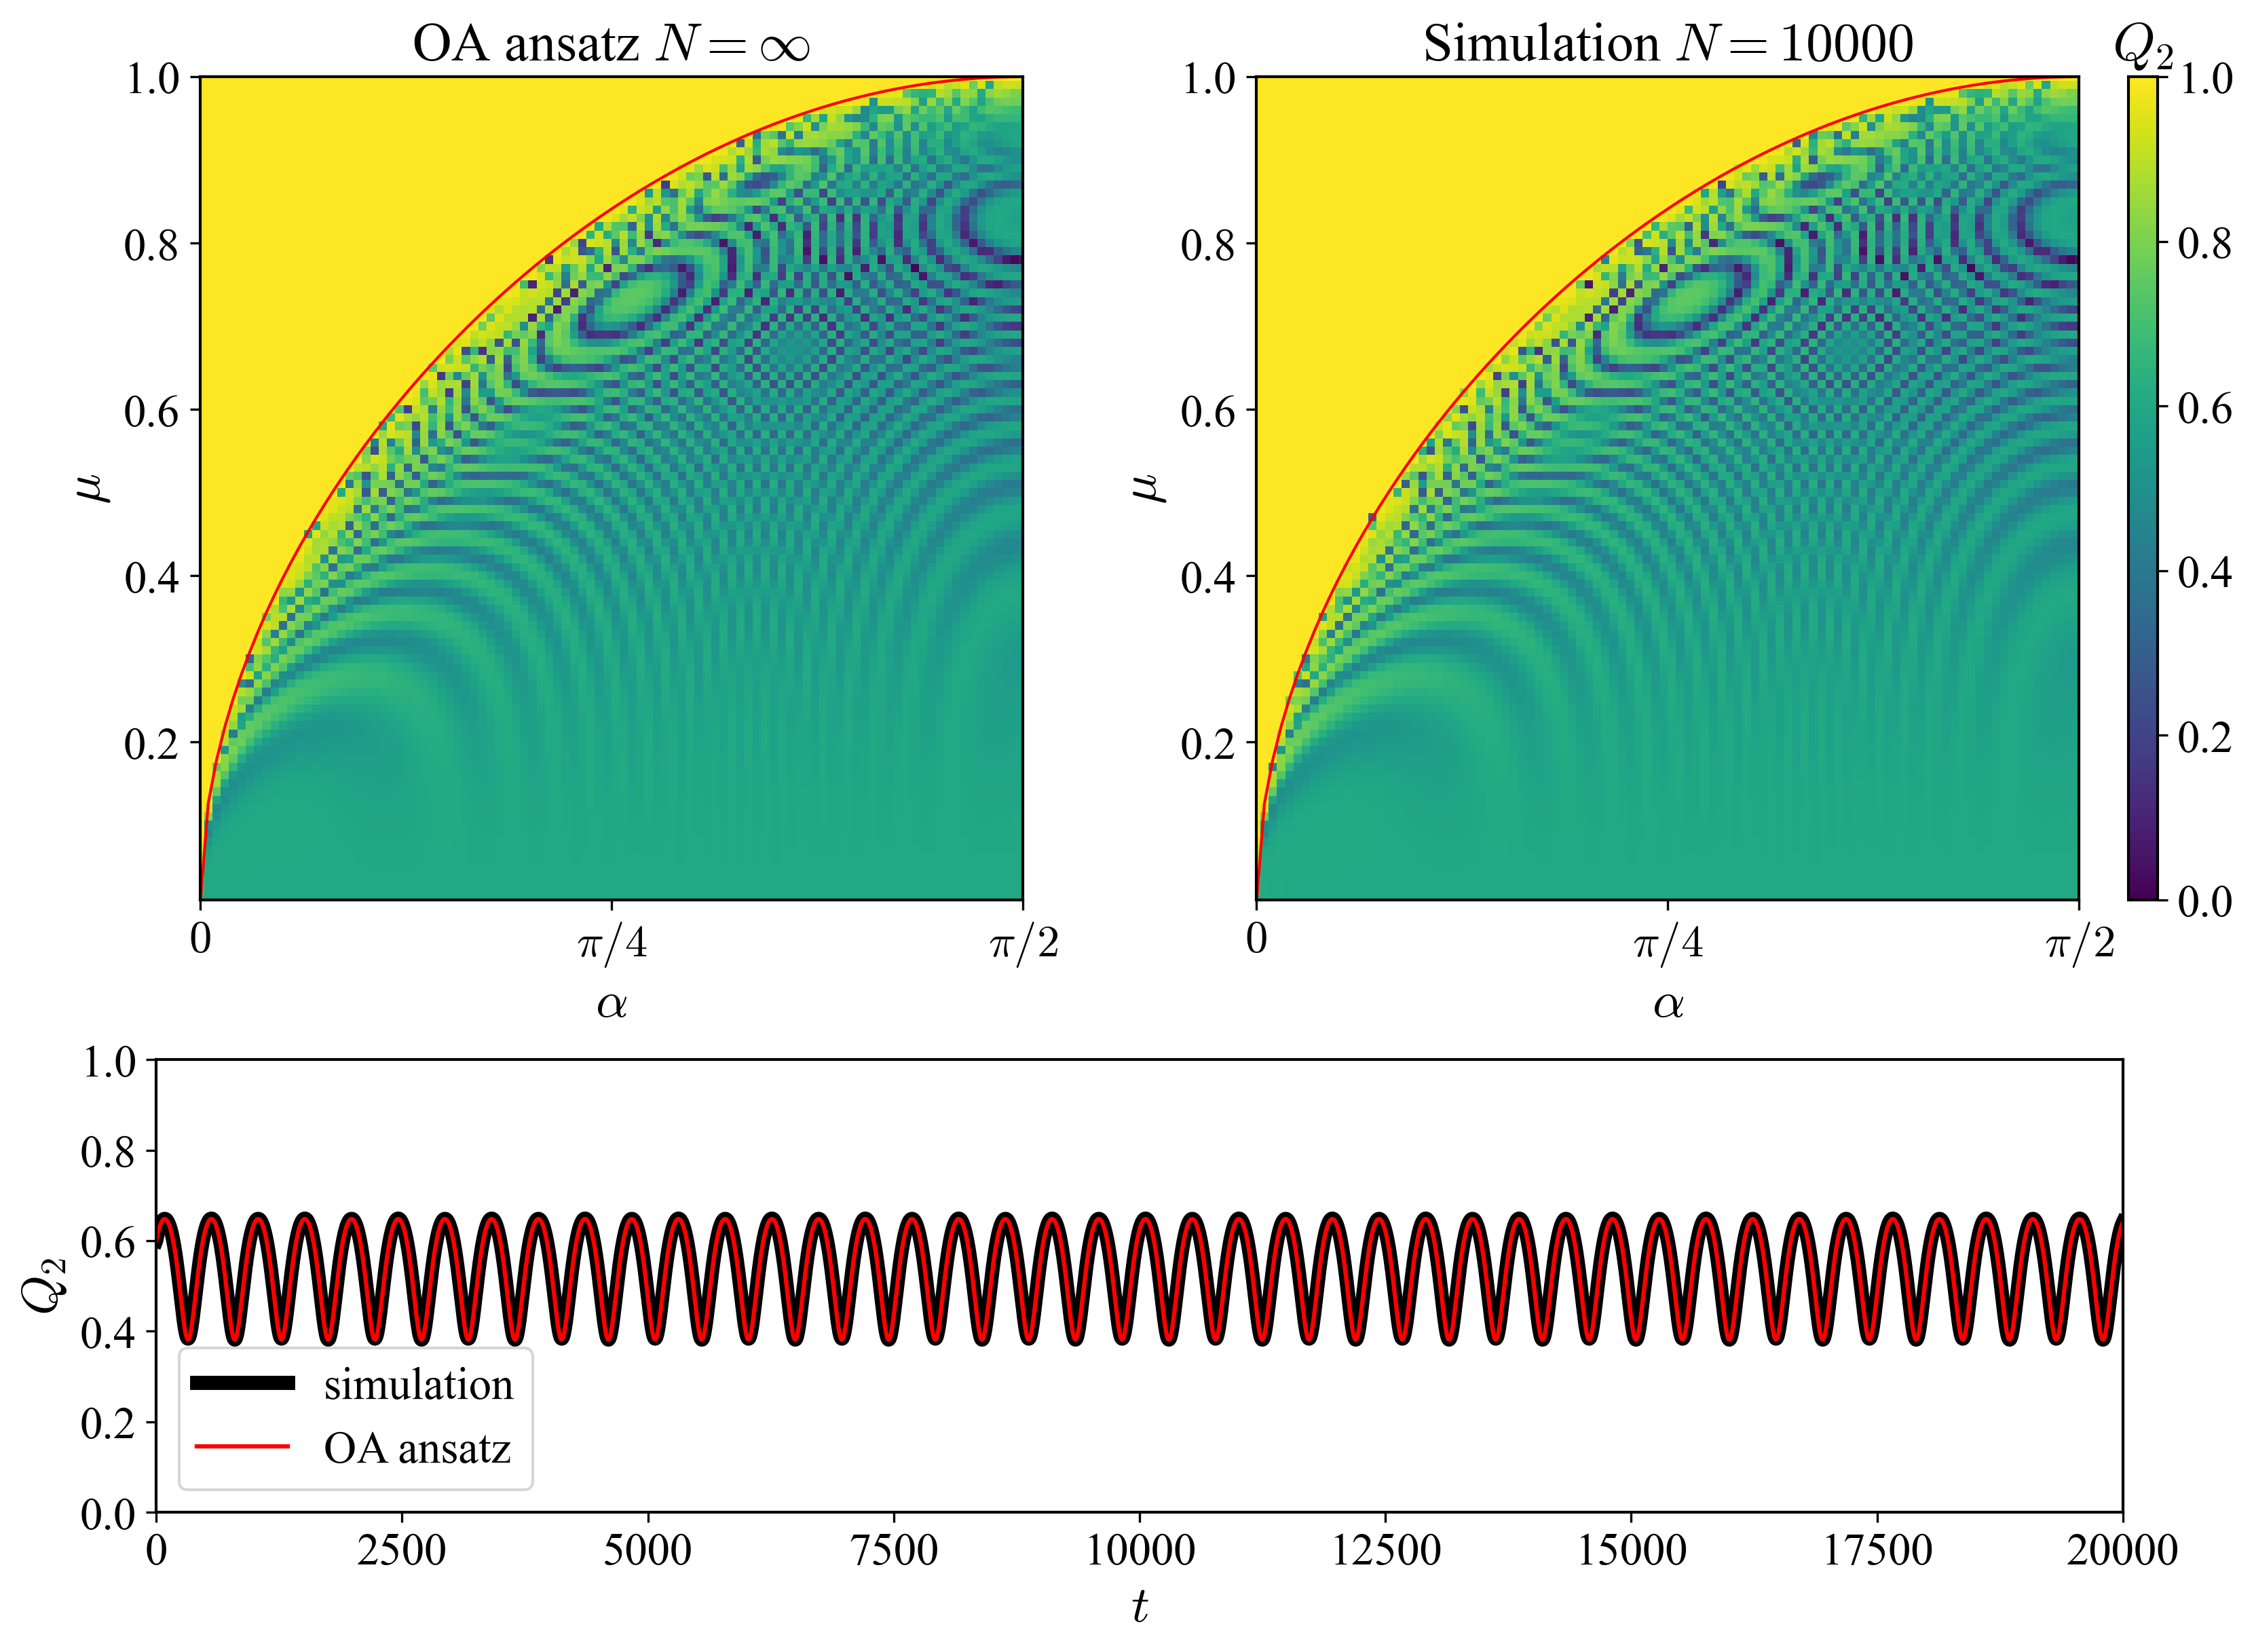

In [21]:
fig = plt.figure(figsize=(11, 8), dpi=300, constrained_layout=True)

gs = fig.add_gridspec(
    2, 2,
    height_ratios=[1, 0.55],
    width_ratios=[1, 1]
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])

index = -1

# -------------------------
# Top-left
# -------------------------
im1 = ax1.pcolormesh(
    alphas, betas, Q2s[:, :, index],
    vmin=0, vmax=1,
    shading='auto'
)
ax1.set_title(r'OA ansatz $N=\infty$')
ax1.set_box_aspect(1)

# -------------------------
# Top-right
# -------------------------
im2 = ax2.pcolormesh(
    alphas, betas, Q2s_sim[:, :, index],
    vmin=0, vmax=1,
    shading='auto'
)
ax2.set_title(r'Simulation $N=10000$')
ax2.set_box_aspect(1)

# -------------------------
# Shared colorbar
# ax2 기준으로 높이 100%짜리 colorbar 생성
# -------------------------
cax = ax2.inset_axes([1.06, 0.0, 0.035, 1.0])
cbar = fig.colorbar(im2, cax=cax)
cbar.ax.set_title(r'$Q_2$')

# -------------------------
# Axis formatting
# -------------------------
for ax in [ax1, ax2]:
    ax.plot(alphas, np.sqrt(np.sin(alphas)), color='red', lw=1)

    ax.set_xlabel(r'$\alpha$')
    ax.set_ylabel(r'$\mu$')

    ax.set_xlim(0, np.pi / 2)
    ax.set_ylim(betas[0], 1)

    ax.set_xticks([0, np.pi/4, np.pi/2])
    ax.set_xticklabels([r'$0$', r'$\pi/4$', r'$\pi/2$'])

# -------------------------
# Bottom time series
# -------------------------
ax3.plot(t, np.abs(Z2bs), label='simulation',lw = 5,color = 'black')
ax3.plot(t, np.abs(Q2), label='OA ansatz',color='red')

ax3.set_xlim(0, 20000)
ax3.set_ylim(0, 1)
ax3.set_xlabel(r'$t$')
ax3.set_ylabel(r'$Q_2$')
ax3.legend()

plt.show()

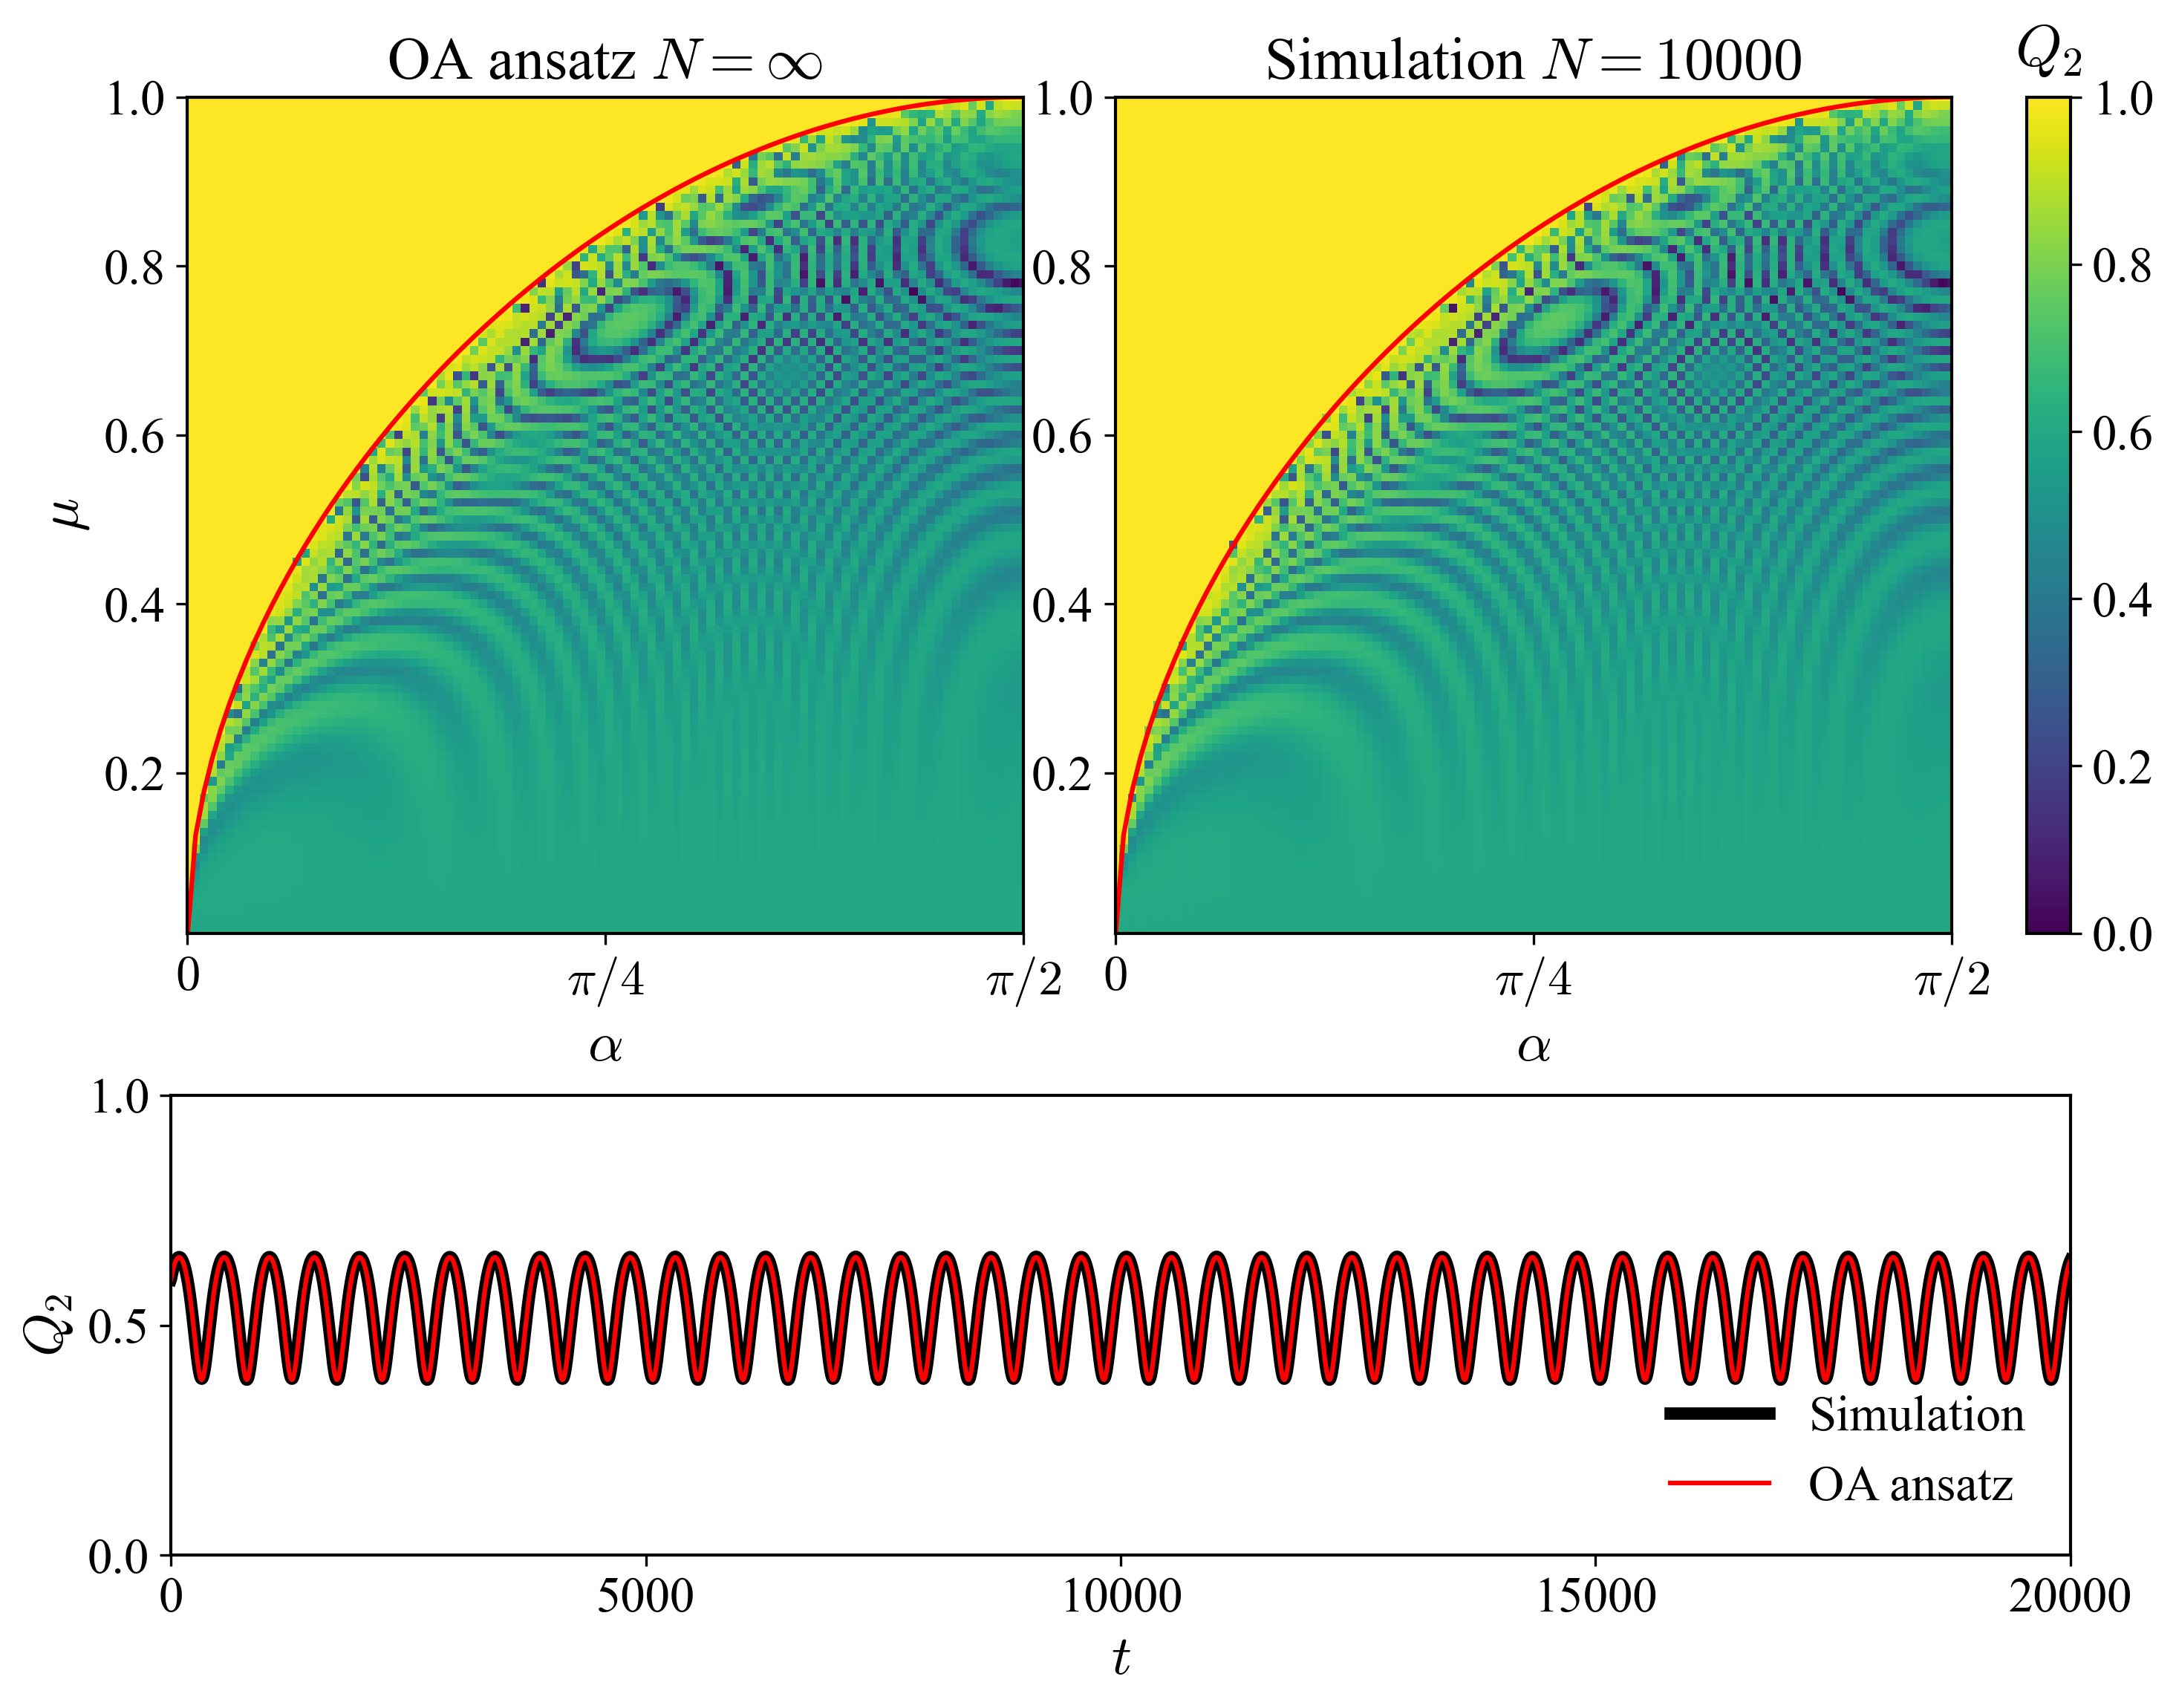

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# 자동 레이아웃 충돌 방지를 위해 constrained_layout=False (기본값) 유지
fig = plt.figure(figsize=(11, 8.5), dpi=300)

# 2행 3열 구조
gs = fig.add_gridspec(
    2, 3,
    height_ratios=[1, 0.55],      # 위/아래 패널 높이 비율
    width_ratios=[1, 1, 0.05],    # 왼쪽패널(1) : 오른쪽패널(1) : 컬러바(0.05)
    wspace=0.1,                   # 좌우 패널 사이의 간격 (더 땡기고 싶으면 0.05 등으로 축소)
    hspace=0.25                   # 상하 패널 사이의 간격
)

# --- 축(Axes) 할당 ---
ax1 = fig.add_subplot(gs[0, 0])   # Top-left
ax2 = fig.add_subplot(gs[0, 1])   # Top-right
cax = fig.add_subplot(gs[0, 2])   # Top-far-right (컬러바 전용)

# [핵심] 아래쪽 패널이 왼쪽부터 컬러바 끝까지 전체 너비를 꽉 채우도록 설정 (:)
ax3 = fig.add_subplot(gs[1, :])   

# --- 비율 강제 ---
# 정사각형 비율을 유지하려면 아래 코드를 사용합니다.
# 단, figsize의 비율과 맞지 않으면 빈 여백이 생길 수 있으므로, 
# 여백이 거슬린다면 set_box_aspect(1)을 지우고 GridSpec이 주는 비율 그대로 쓰는 것도 방법입니다.
ax1.set_box_aspect(1)
ax2.set_box_aspect(1)

# -------------------------
# Top-left (OA ansatz)
# -------------------------
# [중요] 논문 제출 시 pcolormesh로 인해 PDF 파일이 수십 MB로 커지는 것을 막기 위해 rasterized=True 필수
im1 = ax1.pcolormesh(
    alphas, betas, Q2s[:, :, index], 
    vmin=0, vmax=1, shading='auto', rasterized=True
)
ax1.set_title(r'OA ansatz $N=\infty$')
ax1.set_box_aspect(1)

# -------------------------
# Top-right (Simulation)
# -------------------------
im2 = ax2.pcolormesh(
    alphas, betas, Q2s_sim[:, :, index], 
    vmin=0, vmax=1, shading='auto', rasterized=True
)
ax2.set_title(r'Simulation $N=10000$')
ax2.set_box_aspect(1)

# -------------------------
# Shared colorbar
# -------------------------
cbar = fig.colorbar(im2, cax=cax)
cbar.ax.set_title(r'$Q_2$', pad=10)

# -------------------------
# Axis formatting (Top panels)
# -------------------------
for ax in [ax1, ax2]:
    ax.plot(alphas, np.sqrt(np.sin(alphas)), color='red', lw=1.5)
    ax.set_xlabel(r'$\alpha$')
    ax.set_xlim(0, np.pi / 2)
    ax.set_ylim(betas[0], 1)
    ax.set_xticks([0, np.pi/4, np.pi/2])
    ax.set_xticklabels([r'$0$', r'$\pi/4$', r'$\pi/2$'])
ax1.set_ylabel(r'$\mu$')

# -------------------------
# Bottom time series (Simulation vs OA)
# -------------------------
# 아래 패널은 작은데 lw=5는 너무 두꺼워 떡져 보일 수 있어 조절했습니다.
ax3.plot(t, np.abs(Z2bs), label='Simulation', lw=4, color='black')
ax3.plot(t, np.abs(Q2), label='OA ansatz', lw=1.5, color='red')

# 말씀하신 전체 시뮬레이션 시간 반영
ax3.set_yticks([0,0.5,1])  # y축 눈금 추가
ax3.set_xticks([0,5000,10000,15000,20000])  # x축 눈금 추가
ax3.set_xlim(0, 20000) 
ax3.set_ylim(0, 1)
ax3.set_xlabel(r'$t$')
ax3.set_ylabel(r'$Q_2$')

# 논문 그림은 독자가 캡션을 안 봐도 어떤 파라미터인지 직관적으로 알 수 있게 박스 처리해 주면 좋습니다.

ax3.legend(loc='lower right', framealpha=0)

plt.show()

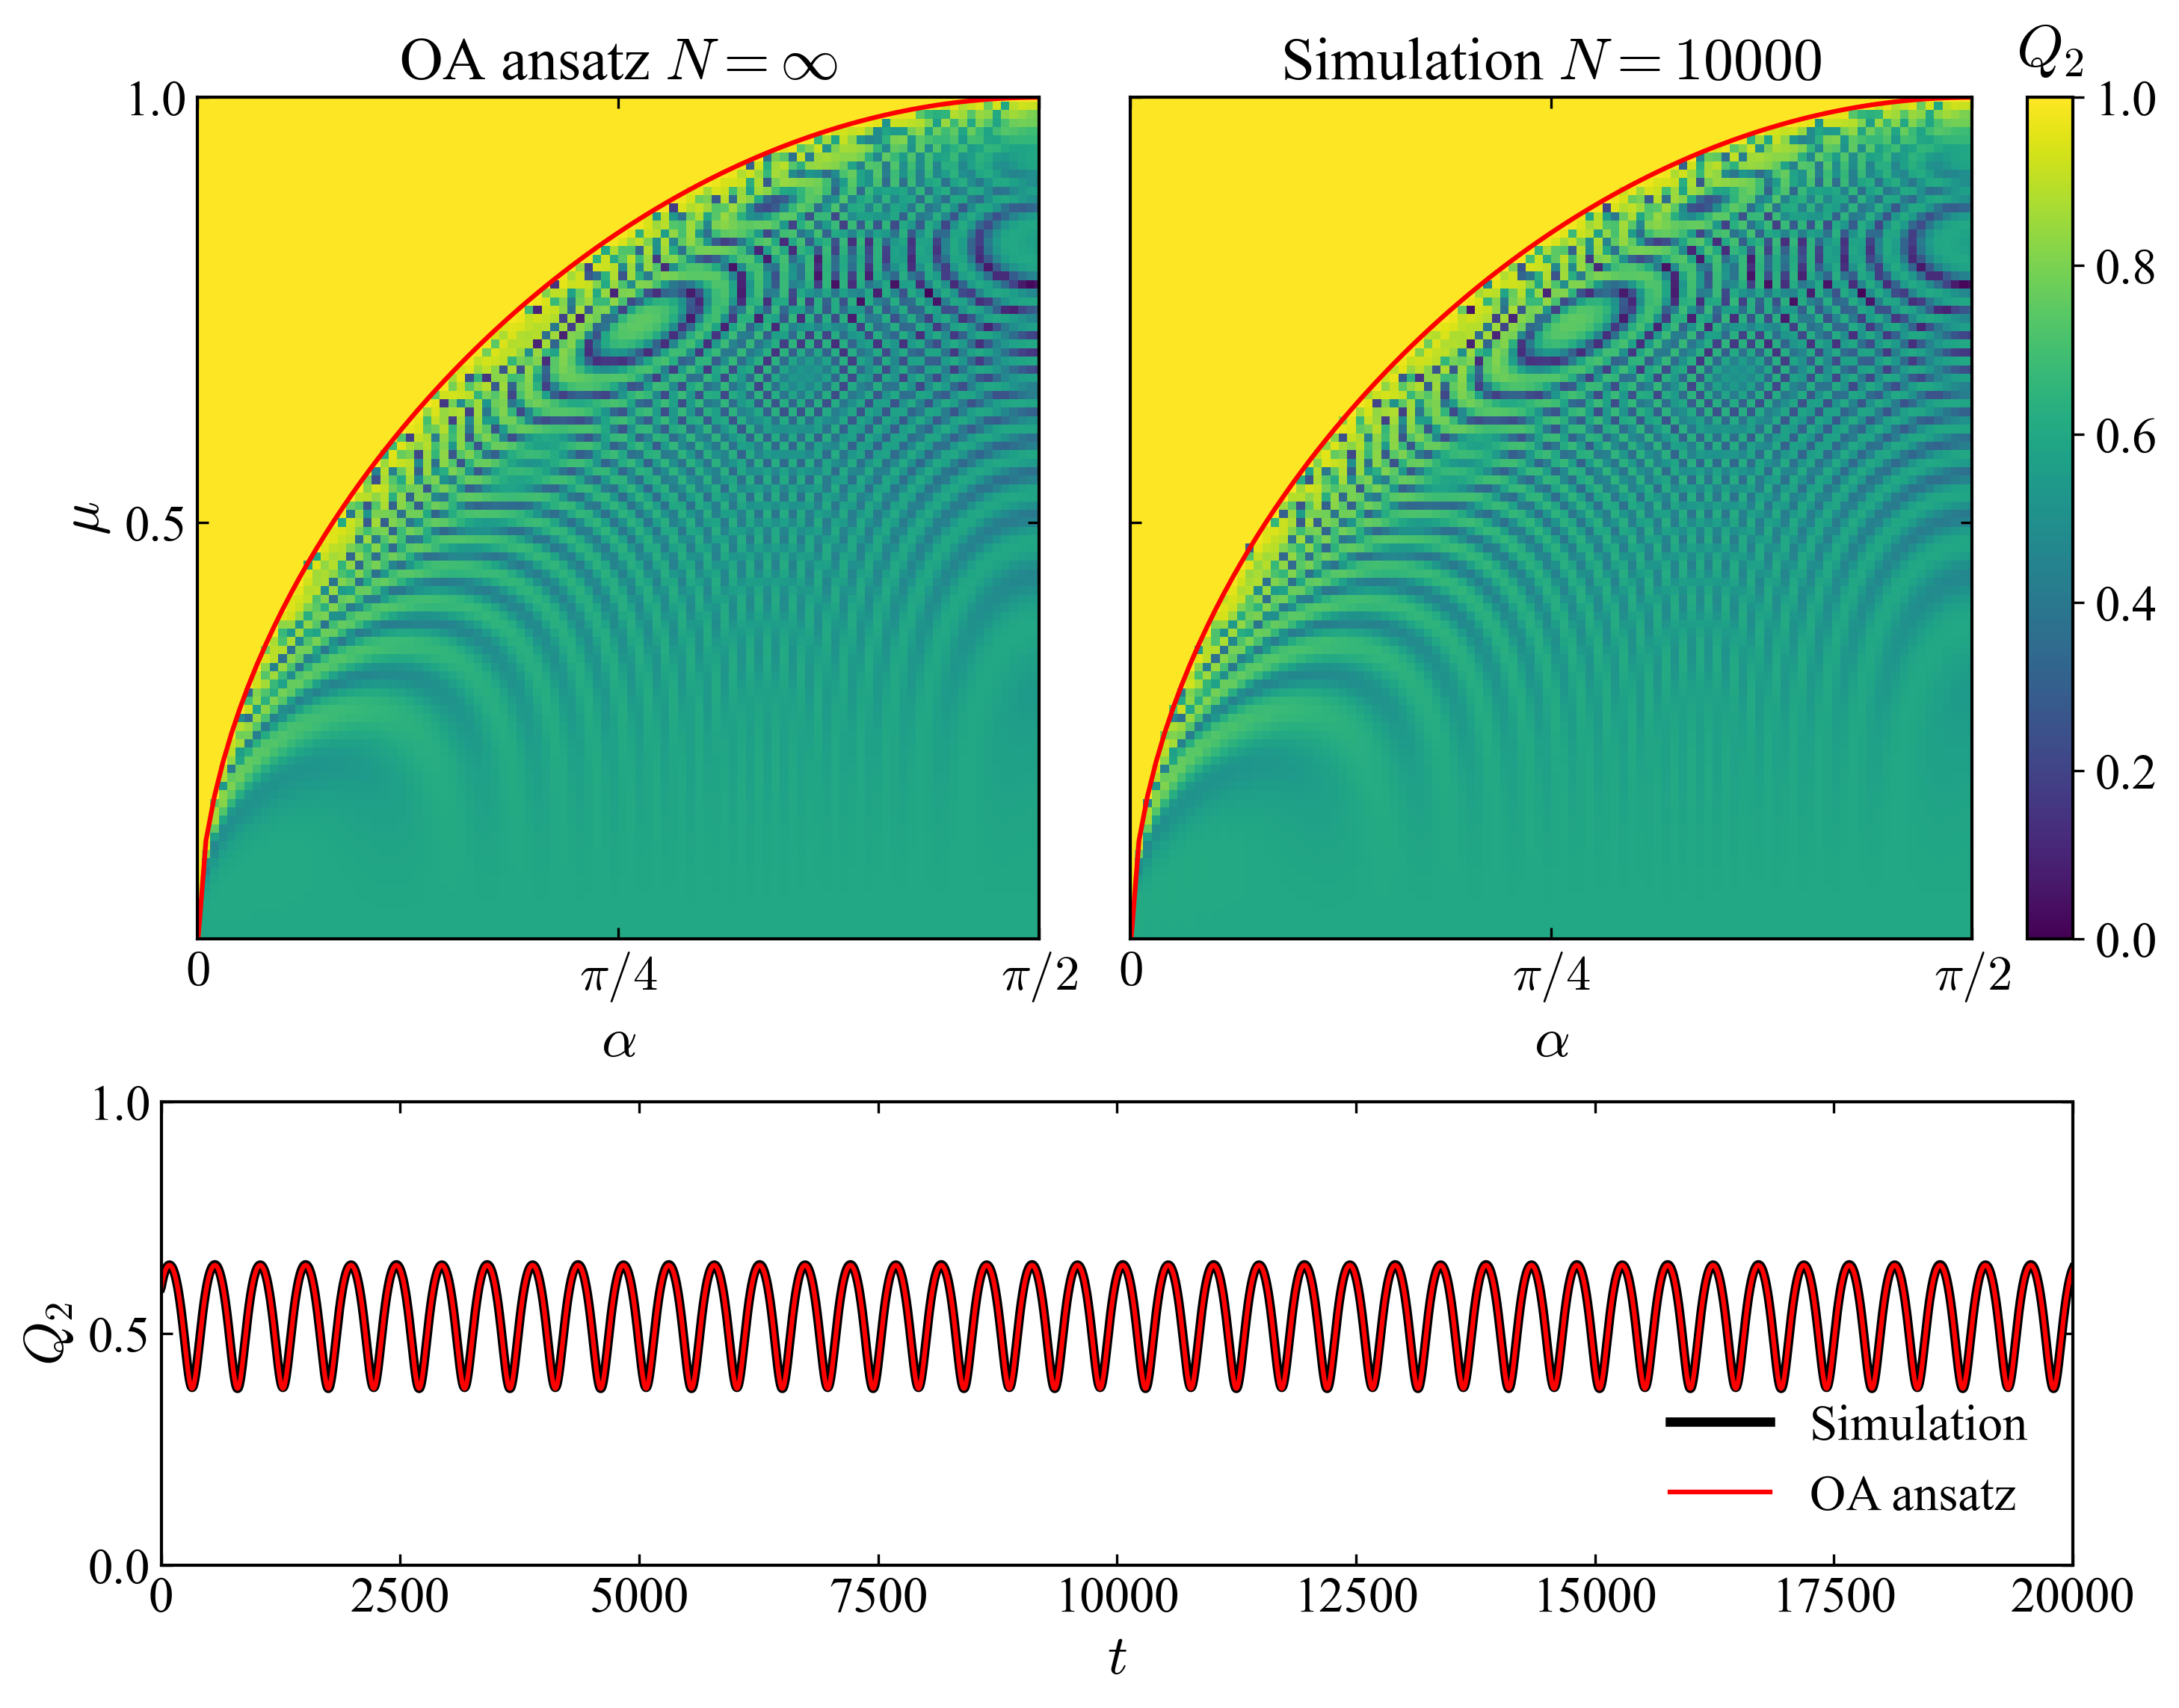

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Figure 및 GridSpec 설정
fig = plt.figure(figsize=(11, 8.5), dpi=300)

gs = fig.add_gridspec(
    2, 3,
    height_ratios=[1, 0.55],
    width_ratios=[1, 1, 0.05], # 왼쪽(1) : 오른쪽(1) : 컬러바(0.05)
    wspace=0.03,               # ax1과 ax2 사이 간격을 거의 없앰
    hspace=0.25                # 위아래 패널 간격
)

# 2. Axes 할당 (ax2는 ax1과 y축 공유, ax3는 전체 너비 차지)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1], sharey=ax1) 
cax = fig.add_subplot(gs[0, 2])
ax3 = fig.add_subplot(gs[1, :]) # 아래 패널이 왼쪽부터 컬러바 끝까지 꽉 채움

ax1.set_box_aspect(1)
ax2.set_box_aspect(1)

# 3. 데이터 플로팅 (rasterized=True 추가)
im1 = ax1.pcolormesh(
    alphas, betas, Q2s[:, :, index],
    vmin=0, vmax=1, shading='auto', rasterized=True
)
ax1.set_title(r'OA ansatz $N=\infty$')

im2 = ax2.pcolormesh(
    alphas, betas, Q2s_sim[:, :, index],
    vmin=0, vmax=1, shading='auto', rasterized=True
)
ax2.set_title(r'Simulation $N=10000$')

# 4. 컬러바 설정
cbar = fig.colorbar(im2, cax=cax)
cbar.ax.set_title(r'$Q_2$', pad=10)

# 5. 위쪽 패널 축 설정 (ax1, ax2)
# 5. 위쪽 패널 축 설정 부분 수정
for ax in [ax1, ax2]:
    ax.plot(alphas, np.sqrt(np.sin(alphas)), color='red', lw=1.5)
    ax.set_xlabel(r'$\alpha$')
    ax.set_xlim(0, np.pi / 2)
    ax.set_ylim(betas[0], 1)
    ax.set_xticks([0, np.pi/4, np.pi/2])
    ax.set_xticklabels([r'$0$', r'$\pi/4$', r'$\pi/2$'])
    
    # ★ 추가: y축 눈금을 0.0, 0.5, 1.0 세 개만 표시하도록 강제 지정
    ax.set_yticks([ 0.5, 1])
    ax.set_yticklabels([ '0.5', '1.0'])
    
    ax.tick_params(direction='in', top=True, right=True)

# ax1에만 y축 라벨을 넣고, ax2는 y축 라벨과 숫자 숨김 (간격 축소를 위함)
ax1.set_ylabel(r'$\mu$')
ax2.set_ylabel('')
ax2.tick_params(labelleft=False)

# 6. 아래쪽 패널 (ax3) 설정
ax3.plot(t, np.abs(Z2bs), label='Simulation', lw=3, color='black')
ax3.plot(t, np.abs(Q2), label='OA ansatz', lw=1.5, color='red')

ax3.set_xlim(0, 20000)
ax3.set_ylim(0, 1)
ax3.set_xlabel(r'$t$')
ax3.set_ylabel(r'$Q_2$')

# ★ 추가: 아래 패널도 y축 눈금을 시원하게 설정
ax3.set_yticks([0, 0.5, 1])
ax3.set_yticklabels(['0.0', '0.5', '1.0'])

ax3.tick_params(direction='in', top=True, right=True)
ax3.legend(loc='lower right', framealpha=0)

# 7. 논문용 고해상도 저장 (여백 최소화)
# plt.savefig('figure_name.pdf', format='pdf', bbox_inches='tight', dpi=300)

plt.show()

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


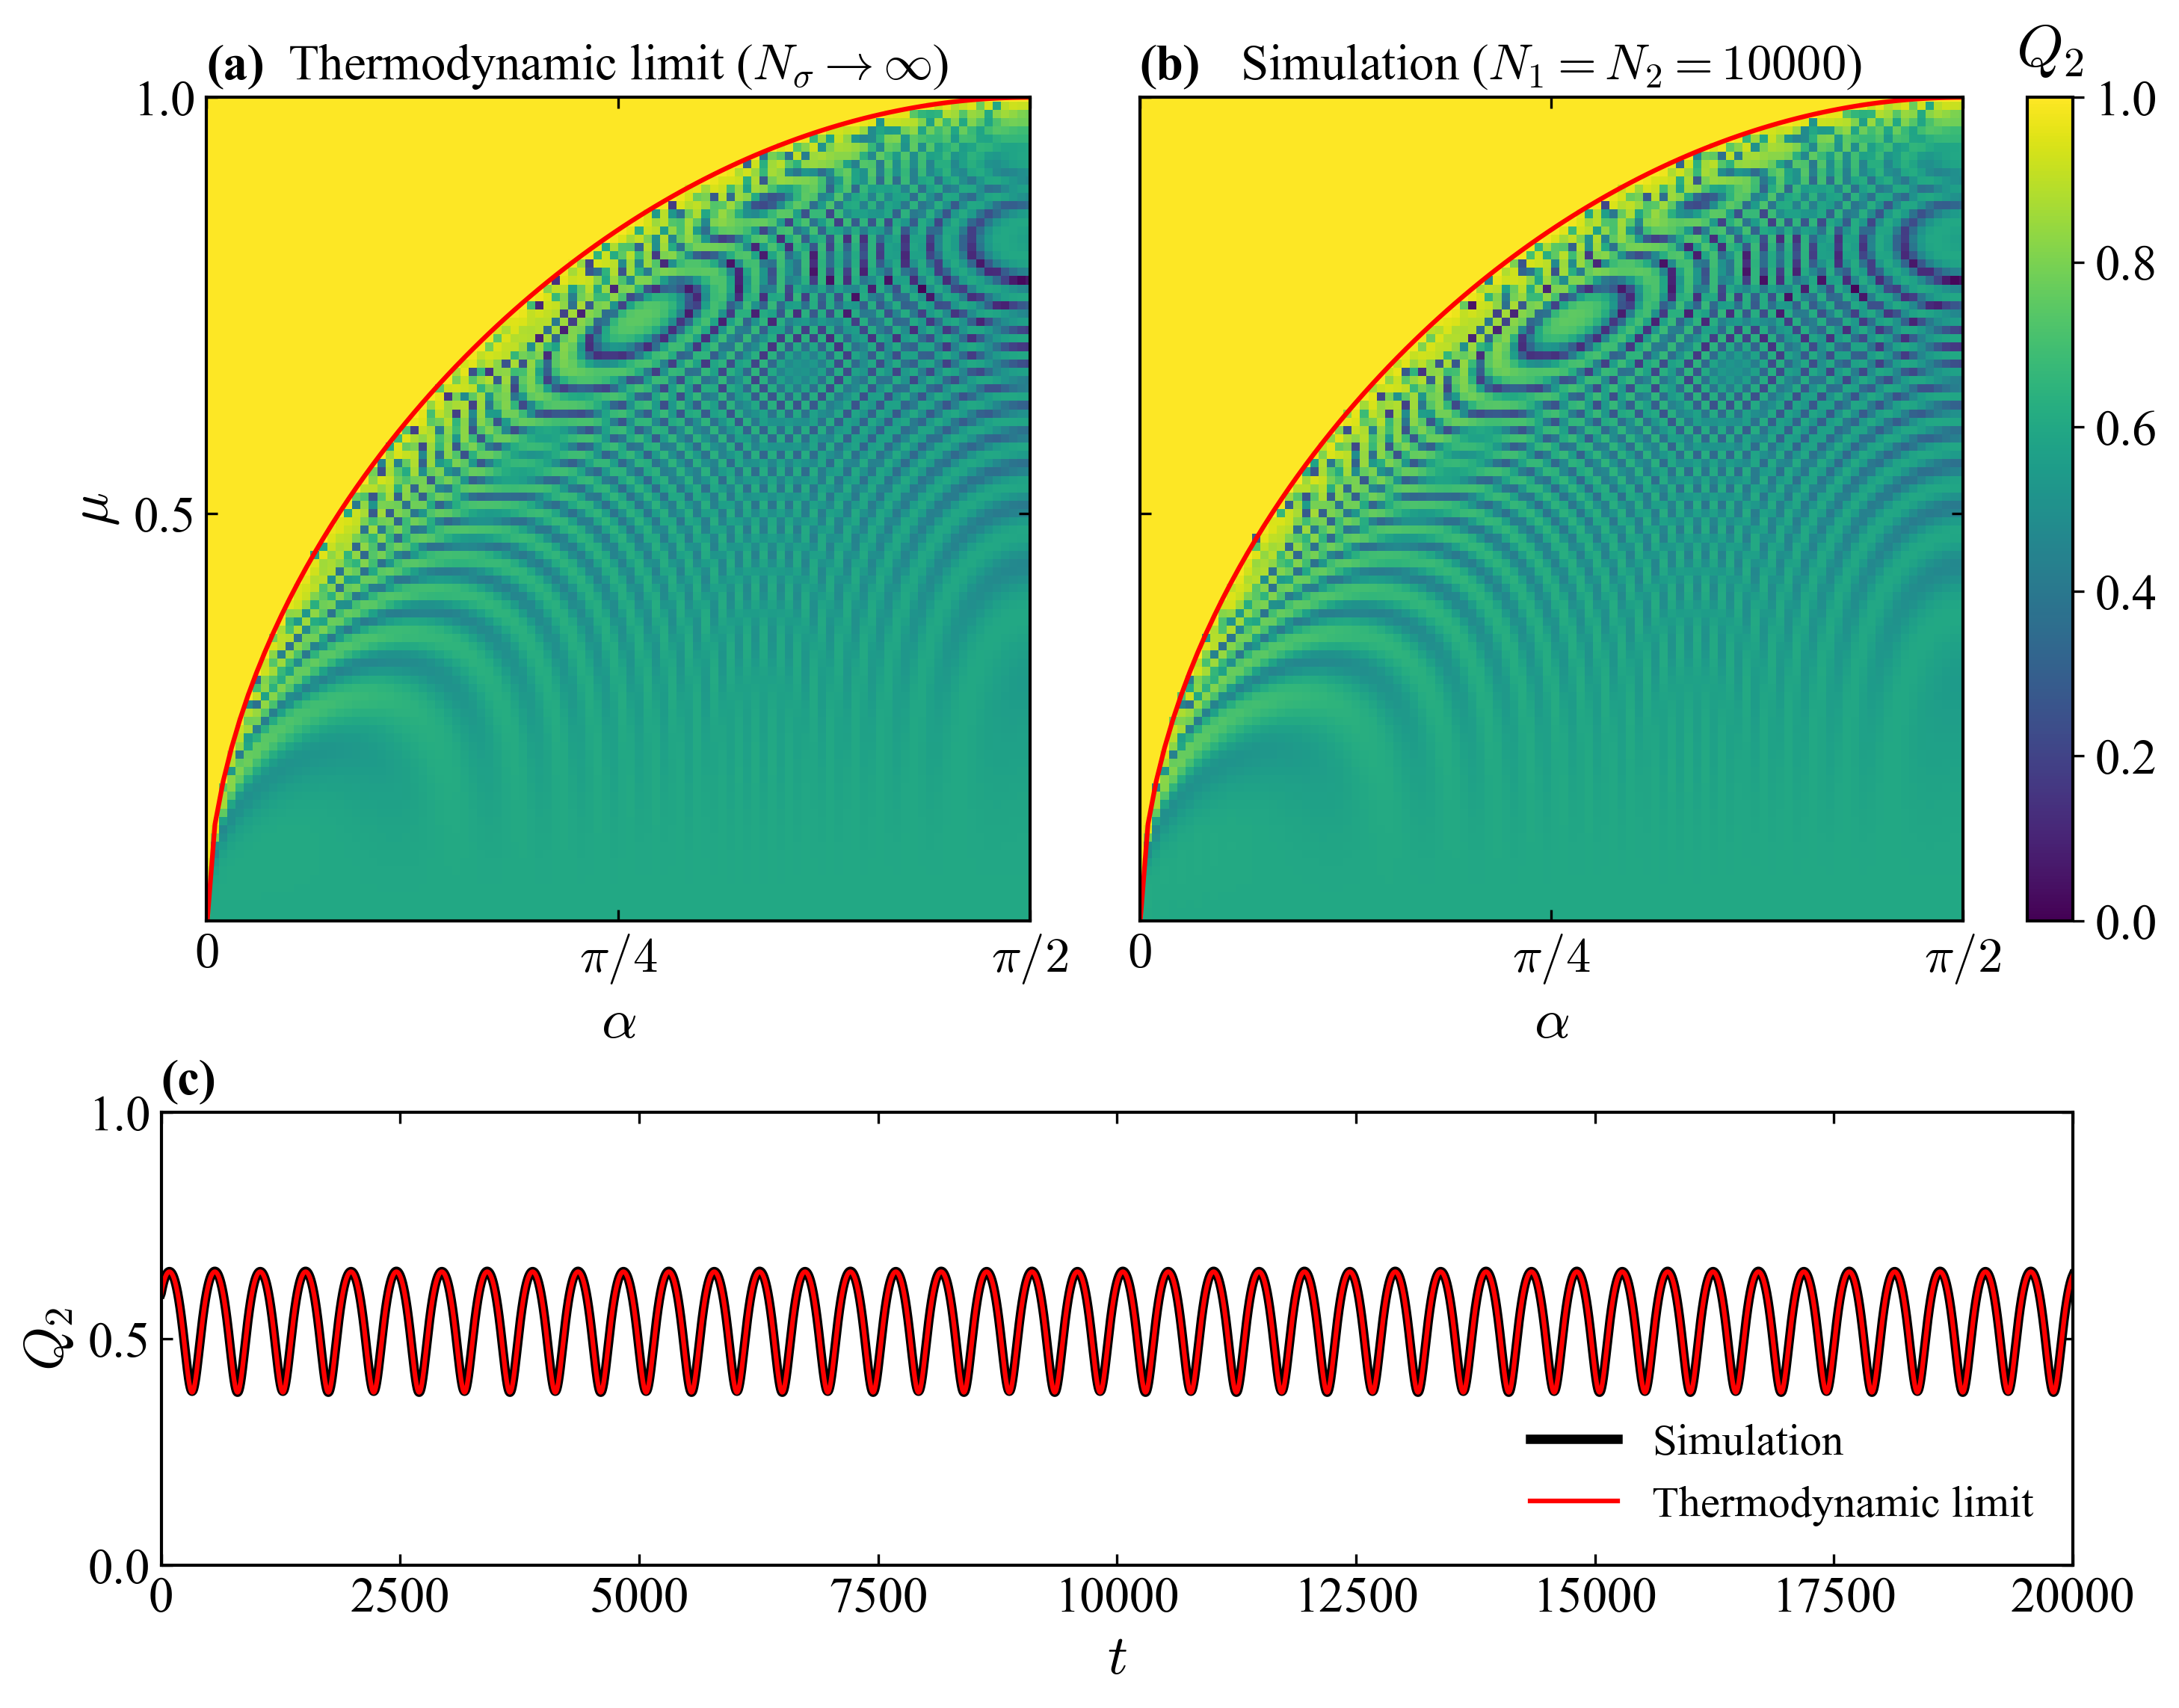

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Figure 및 GridSpec 설정
fig = plt.figure(figsize=(11, 8.5), dpi=300)

gs = fig.add_gridspec(
    2, 3,
    height_ratios=[1, 0.55],
    width_ratios=[1, 1, 0.05], # 왼쪽(1) : 오른쪽(1) : 컬러바(0.05)
    wspace=0.03,               # ax1과 ax2 사이 간격 바짝 붙임
    hspace=0.30                # 위아래 간격 ((c) 라벨 공간 확보)
)

# 2. Axes 할당 (ax2는 ax1과 y축 공유, ax3는 전체 차지)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1], sharey=ax1) 
cax = fig.add_subplot(gs[0, 2])
ax3 = fig.add_subplot(gs[1, :])

ax1.set_box_aspect(1)
ax2.set_box_aspect(1)

# ---------------------------------------------------------
# 3. 위쪽 패널 (a), (b) : Phase Diagram
# ---------------------------------------------------------
im1 = ax1.pcolormesh(
    alphas, betas, Q2s[:, :, index],
    vmin=0, vmax=1, shading='auto', rasterized=True
)
# ★ loc='left'로 라벨을 좌측 상단에, 메인 제목은 중앙에 각각 분리하여 깔끔하게 배치
ax1.set_title(r'(a)', loc='left', fontweight='bold', fontsize=16)
ax1.set_title(r'Thermodynamic limit ($N_\sigma \rightarrow \infty$)', loc='center', fontsize=16)

im2 = ax2.pcolormesh(
    alphas, betas, Q2s_sim[:, :, index],
    vmin=0, vmax=1, shading='auto', rasterized=True
)
ax2.set_title(r'(b)', loc='left', fontweight='bold', fontsize=16)
ax2.set_title(r'Simulation ($N_1 = N_2 = 10000$)', loc='center', fontsize=16)

# 컬러바 설정
cbar = fig.colorbar(im2, cax=cax)
cbar.ax.set_title(r'$Q_2$', pad=10)

# 위쪽 패널 축 설정
for ax in [ax1, ax2]:
    ax.plot(alphas, np.sqrt(np.sin(alphas)), color='red', lw=1.5)
    
    # 디테일을 줄인 직관적인 수학 기호 축
    ax.set_xlabel(r'$\alpha$')
    ax.set_xlim(0, np.pi / 2)
    ax.set_ylim(betas[0], 1)
    
    ax.set_xticks([0, np.pi/4, np.pi/2])
    ax.set_xticklabels([r'$0$', r'$\pi/4$', r'$\pi/2$'])
    
    # y축 눈금을 시원하게 설정
    ax.set_yticks([0.5, 1])
    ax.set_yticklabels(['0.5', '1.0'])
    
    ax.tick_params(direction='in', top=True, right=True)

# 축 공유로 인한 ax2 라벨/눈금 숫자 숨김
ax1.set_ylabel(r'$\mu$')
ax2.set_ylabel('')
ax2.tick_params(labelleft=False)

# ---------------------------------------------------------
# 4. 아래쪽 패널 (c) : Time Series
# ---------------------------------------------------------
# ★ (c) 라벨 추가
ax3.set_title(r'(c)', loc='left', fontweight='bold', fontsize=16)

ax3.plot(t, np.abs(Z2bs), label='Simulation', lw=3, color='black')
ax3.plot(t, np.abs(Q2), label='Thermodynamic limit', lw=1.5, color='red')

ax3.set_xlim(0, 20000)
ax3.set_ylim(0, 1)

# 심플한 축 라벨
ax3.set_xlabel(r'$t$')
ax3.set_ylabel(r'$Q_2$')

# 위쪽과 통일된 y축 눈금
ax3.set_yticks([0, 0.5, 1])
ax3.set_yticklabels(['0.0', '0.5', '1.0'])

ax3.tick_params(direction='in', top=True, right=True)

# ★ 논문용 디테일: 범례 박스의 테두리를 없애고 배경에 자연스럽게 녹아들도록 설정
ax3.legend(loc='lower right', frameon=False, fontsize=14)

# ---------------------------------------------------------
# 5. 출력 및 논문용 고해상도 저장
# ---------------------------------------------------------
plt.savefig('fig_phase_diagram.pdf', format='pdf', bbox_inches='tight', dpi=300)

plt.show()